## Exploration data

In [101]:
from operator import index

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

data: pd.DataFrame = pd.read_csv("train.csv")
data_numeric_only = data.select_dtypes(exclude=['object', 'string'])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Splitting data, Correlation matrix, Histograms

Text(0, 0.5, 'Frequency')

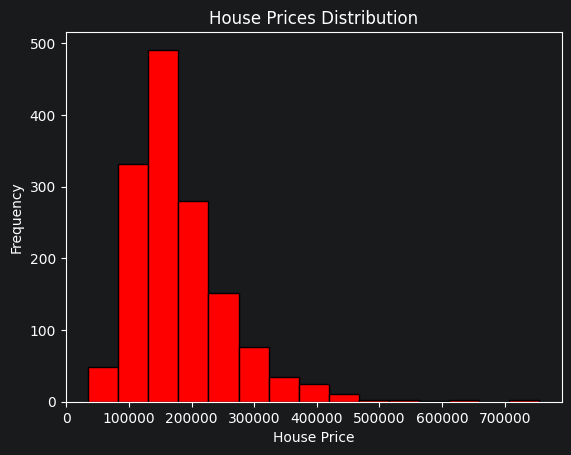

In [102]:
X = data_numeric_only.drop(columns='SalePrice')
y = data_numeric_only['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.hist(y, bins=15, color='red', edgecolor='black')
plt.title("House Prices Distribution")
plt.xlabel("House Price")
plt.ylabel("Frequency")


In [103]:
corr_matrix = data_numeric_only.corr()['SalePrice']
print(corr_matrix)

Id              -0.021917
MSSubClass      -0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond     -0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2      -0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF    -0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath    -0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch   -0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal         -0.021190
MoSold           0.046432
YrSold          -0.028923
SalePrice        1.000000
Name: SalePr

## Filling NaN values, First simple model

In [104]:
imputer = SimpleImputer(strategy='median')
X_clean = imputer.fit_transform(X_train)

lin_reg = LinearRegression()
cross_validation = cross_val_score(lin_reg, X_clean, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"RMSE: {np.mean(cross_validation * -1)}")

RMSE: 37292.85706599731


## Encoding categorical attributes and scaling

In [105]:
X = data.drop(columns=['SalePrice', 'Id'])
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()
cat_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore'))
all_data = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])
full_model = make_pipeline(all_data, LinearRegression())

cross_validation = cross_val_score(full_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"RMSE: {np.mean(cross_validation * -1)}")

RMSE: 37570.690715720695


## Regularization with Ridge, GridSearchCV

In [106]:
full_model = make_pipeline(all_data, Ridge())
params = {'ridge__alpha': [17, 18, 19, 20, 21, 22, 23, 24]}

grid_search = GridSearchCV(
    estimator=full_model,
    param_grid=params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_ * -1)

{'ridge__alpha': 18}
32497.72617131459


## Regularization with LASSO, GridSearchCV

In [107]:
full_model = make_pipeline(all_data, Lasso())
params = {'lasso__alpha': [150, 170, 180, 190, 200, 220, 230, 240, 250]}

grid_search = GridSearchCV(
    estimator=full_model,
    param_grid=params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_ * -1)

{'lasso__alpha': 190}
31973.78102475263


## Regularization with ElasticNet, GridSearchCV

In [108]:
full_model = make_pipeline(all_data, ElasticNet(max_iter=3000))
params = {
    'elasticnet__alpha': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5],
    'elasticnet__l1_ratio': [0.78, 0.79, 0.8, 0.81, 0.82, 0.83]
}

grid_search = GridSearchCV(
    estimator=full_model,
    param_grid=params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_ * -1)

{'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 0.8}
32497.58474082165


## Final model

In [109]:
final_model = make_pipeline(all_data, Lasso(alpha=190))
final_model.fit(X_train, y_train)
predicted = final_model.predict(X_test)
rmse = root_mean_squared_error(y_test, predicted)
print(f"RMSE: {rmse}")

RMSE: 29640.958633703576


## Submission for Kaggle

In [110]:
X_test_data = pd.read_csv("test.csv")

final_model = make_pipeline(all_data, Lasso(alpha=190))
final_model.fit(X, y)
X_test_features = X_test_data.drop(columns='Id')
predicted = final_model.predict(X_test_data)

submission = pd.DataFrame({
    'Id': X_test_data['Id'],
    'SalePrice': predicted
})

submission.to_csv("submission.csv", index=False)